# Integer Analysis

Analyzing data for only input values that are integers to ensure trends reproduce.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
# All models (excluding broken qwen3-235b)
NON_REASONING_MODELS = ['gpt-4o', 'qwen-coder', 'llama-4']
REASONING_MODELS = ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']
ALL_MODELS = NON_REASONING_MODELS + REASONING_MODELS

# Conditions mapped to subdirectories
CONDITIONS = {
    'regular':   'results',
    'no_guide':  'results_no_guide',
    'math_only': 'results_math_only',
}

# Nice display names & colors
MODEL_DISPLAY = {
    'gpt-4o': 'GPT-4o',
    'qwen-coder': 'Qwen3-Coder-480B',
    'llama-4': 'Llama-4-Maverick',
    'gpt-5.2': 'GPT-5.2 ★',
    'deepseek-v3.1': 'DeepSeek-V3.1 ★',
    'qwen3-235b-thinking': 'Qwen3-235B-Think ★',
    'qwen3-next-thinking': 'Qwen3-Next-Think ★',
}

print(f"Non-reasoning models: {NON_REASONING_MODELS}")
print(f"Reasoning models:     {REASONING_MODELS}")

Non-reasoning models: ['gpt-4o', 'qwen-coder', 'llama-4']
Reasoning models:     ['gpt-5.2', 'deepseek-v3.1', 'qwen3-235b-thinking', 'qwen3-next-thinking']


In [4]:
df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv', sep='\t')
print(f"loaded {len(df):,} rows")
print(f"columns: {df.columns.tolist()}")
print(f"models: {df['model'].unique()}")
print(f"conditions: {df['condition'].unique()}")
print(f"domains: {df['domain'].unique()}")

/tmp/ipykernel_2894885/1187790129.py:1: DtypeWarning: Columns (1,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/results.csv', sep='\t')


loaded 3,182,736 rows
columns: ['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty', 'raw_response', 'model_answer', 'loss', 'reasoning_tokens', 'call_seconds', 'model', 'condition', 'frequency', 'frequency_level', 'is_reasoning', 'display_name', 'is_correct', 'num_decimals', 'num_input_decimals', 'frequency_difficulty']
models: ['claude-haiku-4-5' 'deepseek-v3.1' 'gpt-4o' 'gpt-5.2' 'gpt-oss-120b'
 'llama-4' 'qwen-coder' 'qwen3-235b-thinking']
conditions: ['in_domain_with_guide' 'math_only' 'in_domain_no_guide']
domains: ['bits_bytes' 'clothing_size' 'cooking' 'currency' 'density' 'energy'
 'moles_to_particles' 'speed' 'temperature' 'timezone' 'volume']


In [5]:
_ip_str = df['number'].astype(str)
_ip_clean = _ip_str.str.replace(r'\.0+$', '', regex=True)           # 46.0 → 46
_ip_clean = _ip_clean.str.replace(r'(\.\d*?)0+$', r'\1', regex=True)  # strip trailing 0s after decimal
_has_dot = _ip_clean.str.contains(r'\.', na=False)
df['num_input_decimals'] = (
    _ip_clean.str.split('.').str[-1].str.len()
    .where(_has_dot, 0)
    .astype(int)
)


In [6]:
df_int = df[df['num_input_decimals'] == 0]

In [7]:
df_int.sample(20)

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,model,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty
76001,energy,watermelon,Convert 220 joules of watermelon to kilojoules...,220,0.22,Easy,[REASONING]\nI need to convert 220 joules to k...,0.22,0.000000,391.0,...,claude-haiku-4-5,in_domain_with_guide,2429719.0,common,True,Claude-Haiku-4.5,True,2,0,hard
2721643,volume,astatine,Convert 200 liters of astatine to milliliters....,200,200000.0,Easy,<answer>200000.0</answer>,200000.0,0.000000,NaN,...,llama-4,in_domain_no_guide,14556990.0,very_common,False,Llama-4-Maverick,True,0,0,hard
526419,cooking,cookies,Convert 35 milliliters of cookies to cups.\n\n...,35.0,0.147936,Easy,<answer>0.14794369439080217</answer>,0.147944,0.000000,NaN,...,gpt-5.2,in_domain_with_guide,18154734.0,very_common,True,GPT-5.2 ★,True,16,0,hard
2876638,energy,rice,Convert 1500 kilocalories of rice to kilojoule...,1500.0,6276.0,Easy,6276.0000,6276.0,0.000000,NaN,...,qwen-coder,in_domain_no_guide,1960446.0,common,False,Qwen3-Coder-480B,True,0,0,hard
2528664,volume,californium,Convert 42 teaspoons of californium to millili...,42,207.01470817321425,Easy,<answer>207.0147</answer>,207.0147,0.000000,0.0,...,gpt-oss-120b,in_domain_no_guide,14499758.0,common,False,GPT-OSS-120B,True,4,0,hard
304570,cooking,cookies,Convert 400 cups of cookies to teaspoons.\n\nC...,400,19200.0,Easy,19200.0,19200.0,0.000000,NaN,...,gpt-4o,in_domain_with_guide,6742688.0,common,False,GPT-4o,True,0,0,hard
1439250,timezone,NaN,what is (23+3.0)%24,11:00 PM,2:00 AM,Easy,<answer>2AM</answer>,2AM,0.000000,0.0,...,deepseek-v3.1,math_only,0.0,not_found,True,DeepSeek-V3.1 ★,True,0,0,hard
3137563,timezone,NaN,Convert 8:00 AM in Jakarta time to London time...,8:00 AM,1:00 AM,Easy,[REASONING]\nWe are converting 8:00 AM Jakarta...,1AM,0.000000,NaN,...,qwen3-235b-thinking,in_domain_no_guide,0.0,not_found,True,Qwen3-235B-Think ★,True,0,0,hard
1416154,currency,NaN,what is 7*0.4707931462,7,3.295552023219133,Easy,[REASONING]\nI need to calculate 7 * 0.4707931...,3.2955520234,0.000000,75.0,...,claude-haiku-4-5,math_only,123335391.0,very_common,True,Claude-Haiku-4.5,True,10,0,easy
775367,energy,milk,Convert 20 BTUs of milk to kilowatt-hours.\n\n...,20,0.005861,Easy,<answer>0.0922</answer>,0.0922,1473.001557,0.0,...,gpt-oss-120b,in_domain_with_guide,71043598.0,very_common,False,GPT-OSS-120B,False,4,0,hard


In [8]:
df_int['is_correct'] = df['loss'] == 0.0

/tmp/ipykernel_2894885/2954323092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_int['is_correct'] = df['loss'] == 0.0


In [9]:
df_int.columns

Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty'],
      dtype='object')

In [10]:
df_int.head()

,domain,distractor,prompt,number,answer,difficulty,raw_response,model_answer,loss,reasoning_tokens,...,model,condition,frequency,frequency_level,is_reasoning,display_name,is_correct,num_decimals,num_input_decimals,frequency_difficulty
0,bits_bytes,NaN,Convert 1 bit to byte.\n\nConversion guide:\nC...,1,0.125,Easy,[REASONING]\nThe user is asking to convert 1 b...,0.125,0.0,163.0,...,claude-haiku-4-5,in_domain_with_guide,858798582.0,very_common,True,Claude-Haiku-4.5,True,3,0,easy
1,bits_bytes,NaN,Convert 2 bits to bytes.\n\nConversion guide:\...,2,0.25,Easy,"[REASONING]\nTo convert 2 bits to bytes, I nee...",0.25,0.0,123.0,...,claude-haiku-4-5,in_domain_with_guide,789731532.0,very_common,True,Claude-Haiku-4.5,True,2,0,easy
2,bits_bytes,NaN,Convert 3 bits to bytes.\n\nConversion guide:\...,3,0.375,Easy,[REASONING]\nI need to convert 3 bits to bytes...,0.375,0.0,167.0,...,claude-haiku-4-5,in_domain_with_guide,423151867.0,very_common,True,Claude-Haiku-4.5,True,3,0,easy
3,bits_bytes,NaN,Convert 4 bits to bytes.\n\nConversion guide:\...,4,0.5,Easy,"[REASONING]\nTo convert 4 bits to bytes, I nee...",0.5,0.0,203.0,...,claude-haiku-4-5,in_domain_with_guide,298385028.0,very_common,True,Claude-Haiku-4.5,True,1,0,easy
4,bits_bytes,NaN,Convert 5 bits to bytes.\n\nConversion guide:\...,5,0.625,Easy,[REASONING]\nThe user wants to convert 5 bits ...,0.625,0.0,103.0,...,claude-haiku-4-5,in_domain_with_guide,246823466.0,very_common,True,Claude-Haiku-4.5,True,3,0,easy


In [11]:
df_int['is_reasoning'] = df_int['model'].isin(REASONING_MODELS)
df_int['display_name'] = df_int['model'].map(MODEL_DISPLAY)

/tmp/ipykernel_2894885/58362828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_int['is_reasoning'] = df_int['model'].isin(REASONING_MODELS)
/tmp/ipykernel_2894885/58362828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_int['display_name'] = df_int['model'].map(MODEL_DISPLAY)


In [12]:
# check cols, length of data, and some other things

if df_int is not None:
    print(f"loaded {len(df_int):,} rows")
    print(f"columns: {df_int.columns.tolist()}")
    print(f"models: {df_int['model'].unique()}")
    print(f"conditions: {df_int['condition'].unique()}")
    print(f"domains: {df_int['domain'].unique()}")

df_int.columns

loaded 1,986,888 rows
columns: ['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty', 'raw_response', 'model_answer', 'loss', 'reasoning_tokens', 'call_seconds', 'model', 'condition', 'frequency', 'frequency_level', 'is_reasoning', 'display_name', 'is_correct', 'num_decimals', 'num_input_decimals', 'frequency_difficulty']
models: ['claude-haiku-4-5' 'deepseek-v3.1' 'gpt-4o' 'gpt-5.2' 'gpt-oss-120b'
 'llama-4' 'qwen-coder' 'qwen3-235b-thinking']
conditions: ['in_domain_with_guide' 'math_only' 'in_domain_no_guide']
domains: ['bits_bytes' 'clothing_size' 'cooking' 'currency' 'density' 'energy'
 'moles_to_particles' 'speed' 'temperature' 'timezone' 'volume']


Index(['domain', 'distractor', 'prompt', 'number', 'answer', 'difficulty',
       'raw_response', 'model_answer', 'loss', 'reasoning_tokens',
       'call_seconds', 'model', 'condition', 'frequency', 'frequency_level',
       'is_reasoning', 'display_name', 'is_correct', 'num_decimals',
       'num_input_decimals', 'frequency_difficulty'],
      dtype='object')

In [13]:
# calculate accuracy/correctness based on loss
df_int['is_correct'] = df_int['loss'] == 0.0

# show accuracy by domain, model, condition
df_int.groupby(['domain','model','condition'])['is_correct'].mean().mul(100).reset_index(name='accuracy_%')


/tmp/ipykernel_2894885/152638880.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_int['is_correct'] = df_int['loss'] == 0.0


,domain,model,condition,accuracy_%
0,bits_bytes,claude-haiku-4-5,in_domain_no_guide,78.000000
1,bits_bytes,claude-haiku-4-5,in_domain_with_guide,99.666667
2,bits_bytes,claude-haiku-4-5,math_only,100.000000
3,bits_bytes,deepseek-v3.1,in_domain_no_guide,63.000000
4,bits_bytes,deepseek-v3.1,in_domain_with_guide,84.333333
...,...,...,...,...
251,volume,qwen-coder,in_domain_with_guide,74.381720
252,volume,qwen-coder,math_only,99.500000
253,volume,qwen3-235b-thinking,in_domain_no_guide,91.048387
254,volume,qwen3-235b-thinking,in_domain_with_guide,99.360215


In [14]:
# check overall accuracy by model, condition
df_int.groupby(['model','condition'])['is_correct'].mean().mul(100).reset_index(name='accuracy_%')

,model,condition,accuracy_%
0,claude-haiku-4-5,in_domain_no_guide,74.990280
1,claude-haiku-4-5,in_domain_with_guide,90.785131
2,claude-haiku-4-5,math_only,97.150591
3,deepseek-v3.1,in_domain_no_guide,81.431635
4,deepseek-v3.1,in_domain_with_guide,83.663473
5,deepseek-v3.1,math_only,89.878788
6,gpt-4o,in_domain_no_guide,75.942361
7,gpt-4o,in_domain_with_guide,76.026923
8,gpt-4o,math_only,91.175373
9,gpt-5.2,in_domain_no_guide,78.870448


In [15]:
# make stats dataframe
df_stats = (
    df_int
    .groupby(['model', 'condition', 'domain'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
    .reset_index()
)

df_stats['accuracy_%'] = df_stats['accuracy'].mul(100)
df_stats.head()

,model,condition,domain,accuracy,n,accuracy_%
0,claude-haiku-4-5,in_domain_no_guide,bits_bytes,0.780000,600,78.000000
1,claude-haiku-4-5,in_domain_no_guide,clothing_size,0.197802,273,19.780220
2,claude-haiku-4-5,in_domain_no_guide,cooking,0.881935,18600,88.193548
3,claude-haiku-4-5,in_domain_no_guide,currency,0.003125,11200,0.312500
4,claude-haiku-4-5,in_domain_no_guide,density,0.926559,18600,92.655914


In [16]:
df_int.to_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/integers.csv', sep='\t')

In [17]:
df_stats.to_csv('/data/jane/convert/math_gender/conversion_test/2_analysis/integers_stats.csv', sep='\t')

visualizations

/tmp/ipykernel_1269455/1755254426.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_int['is_correct_pct'] = df_int['is_correct'].astype(float) * 100


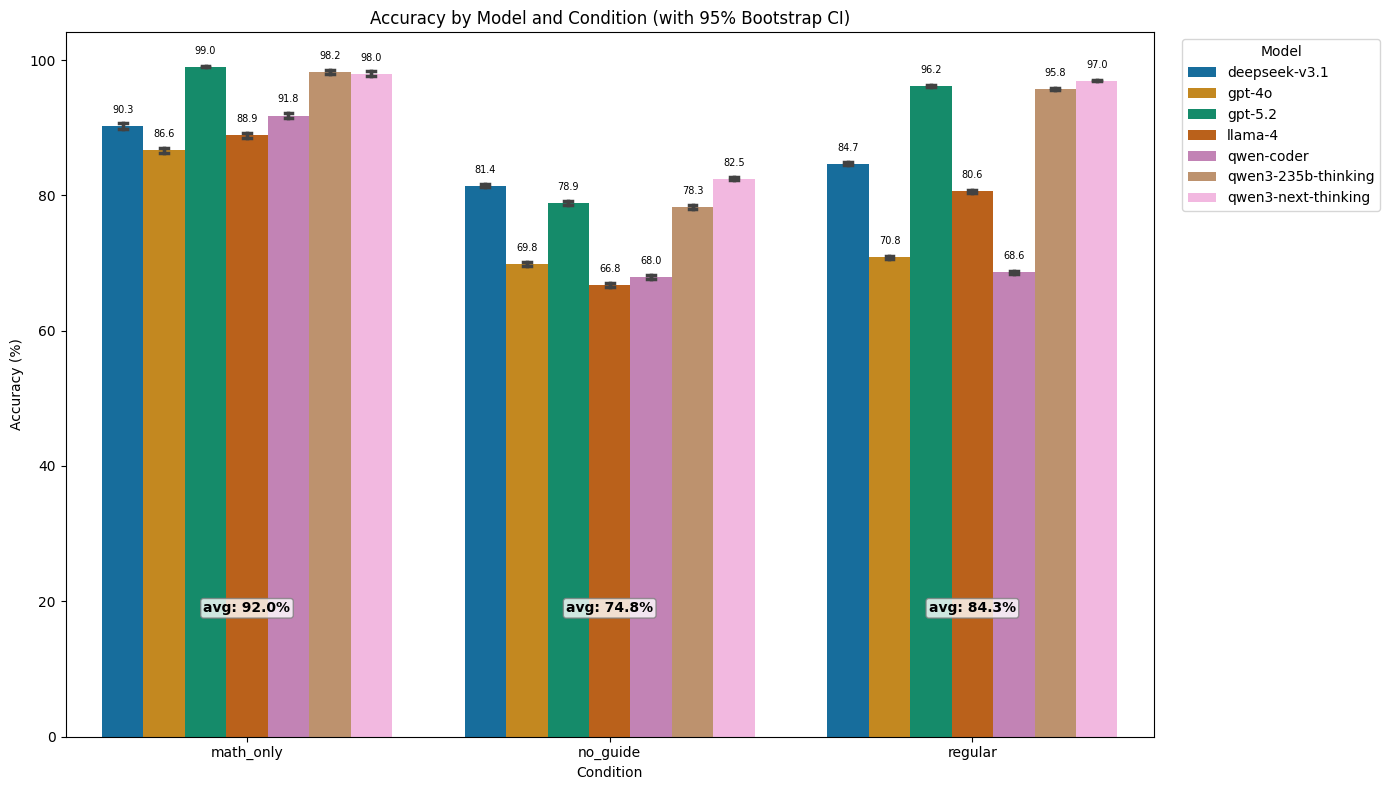

In [16]:
# bar plot of accuracy by model & condition — let seaborn bootstrap 95% CIs from raw data
# multiply is_correct by 100 so y-axis is in percent
df_int['is_correct_pct'] = df_int['is_correct'].astype(float) * 100

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_int, x='condition', y='is_correct_pct', hue='model',
    order=['math_only', 'no_guide', 'regular'],
    errorbar=('ci', 95), n_boot=10000, seed=42,
    palette='colorblind',
    errwidth=2.5, capsize=0.15,   # thicker whiskers, wider caps
)

plt.title('Accuracy by Model and Condition (with 95% Bootstrap CI)')
plt.xlabel('Condition')
plt.ylabel('Accuracy (%)')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')

# add accuracy labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=7, padding=8)

# add average accuracy label for each condition group
cond_avg = df_int.groupby('condition')['is_correct_pct'].mean()
for i, cond in enumerate(ax.get_xticklabels()):
    label = cond.get_text()
    if label in cond_avg.index:
        avg = cond_avg[label]
        ax.text(i, 20, f'avg: {avg:.1f}%', ha='center', va='top',
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8))

plt.tight_layout()
plt.show()

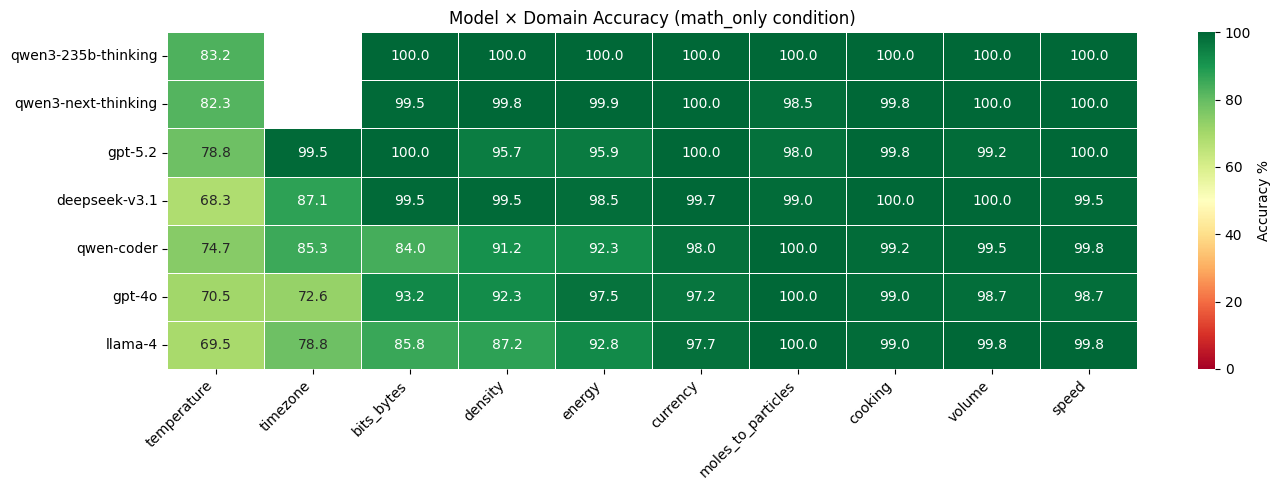

In [17]:
# make a math only heatmap of accuracy by model, condition
heatmap_data = (
    df_stats[df_stats['condition'] == 'math_only']
    .pivot(index='model', columns='domain', values='accuracy_%')
)
# sort rows (models) and columns (domains) by average accuracy descending
heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values(ascending=False).index,
                                heatmap_data.mean(axis=0).sort_values(ascending=True).index]

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',       # show numbers in cells
    cmap='RdYlGn',      
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy %'},
)
plt.title('Model × Domain Accuracy (math_only condition)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

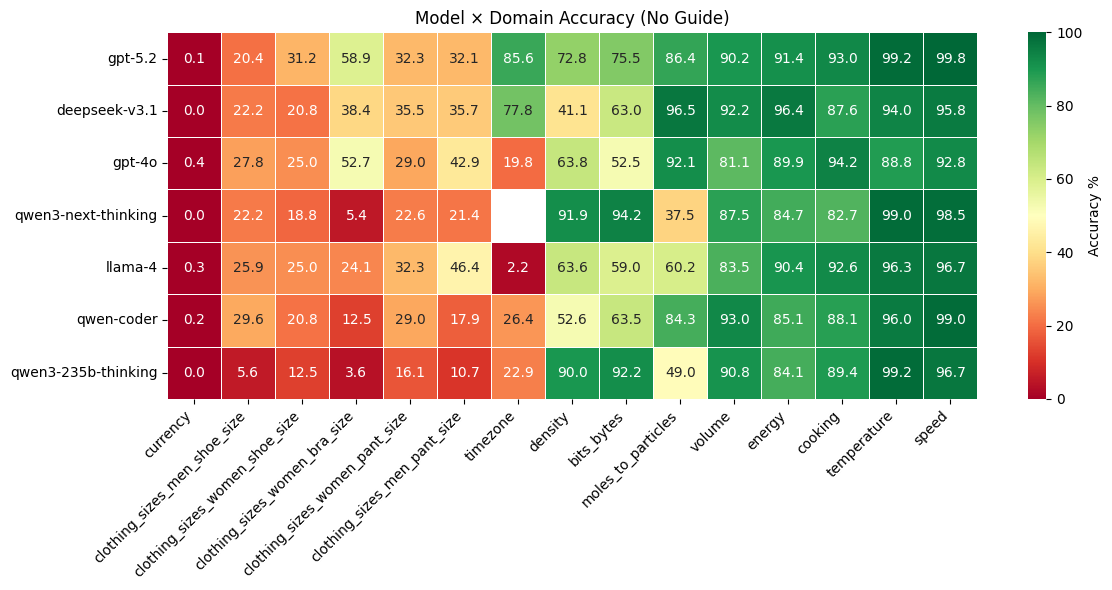

In [18]:
# make a no guide heatmap of accuracy by model, condition
heatmap_data_no_guide = (
    df_stats[df_stats['condition'] == 'no_guide']
    .pivot(index='model', columns='domain', values='accuracy_%')
)
# sort rows (models) and columns (domains) by average accuracy descending
heatmap_data_no_guide = heatmap_data_no_guide.loc[
    heatmap_data_no_guide.mean(axis=1).sort_values(ascending=False).index,
    heatmap_data_no_guide.mean(axis=0).sort_values(ascending=True).index]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_no_guide,
    annot=True, fmt='.1f',       # show numbers in cells
    cmap='RdYlGn',      
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy %'},
)
plt.title('Model × Domain Accuracy (No Guide)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

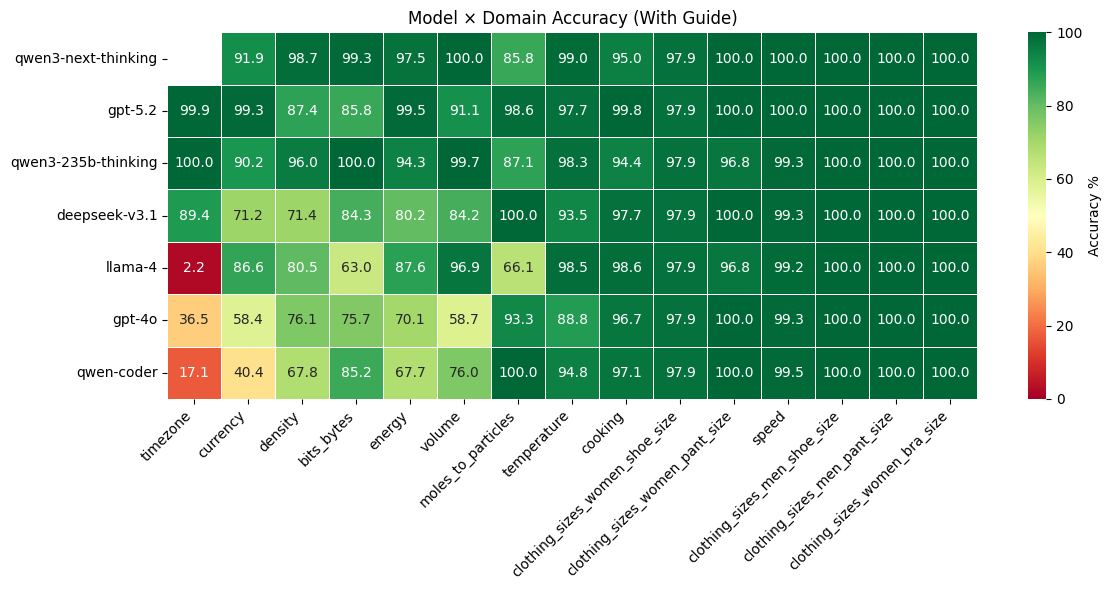

In [19]:
# make a regular (with guide) heatmap of accuracy by model, condition
heatmap_data_with_guide = (
    df_stats[df_stats['condition'] == 'regular']
    .pivot(index='model', columns='domain', values='accuracy_%')
)
# sort rows (models) and columns (domains) by average accuracy descending
heatmap_data_with_guide = heatmap_data_with_guide.loc[
    heatmap_data_with_guide.mean(axis=1).sort_values(ascending=False).index,
    heatmap_data_with_guide.mean(axis=0).sort_values(ascending=True).index]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data_with_guide,
    annot=True, fmt='.1f',       # show numbers in cells
    cmap='RdYlGn',      
    vmin=0, vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy %'},
)
plt.title('Model × Domain Accuracy (With Guide)')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Text(0.5, 0, 'Accuracy (%)')

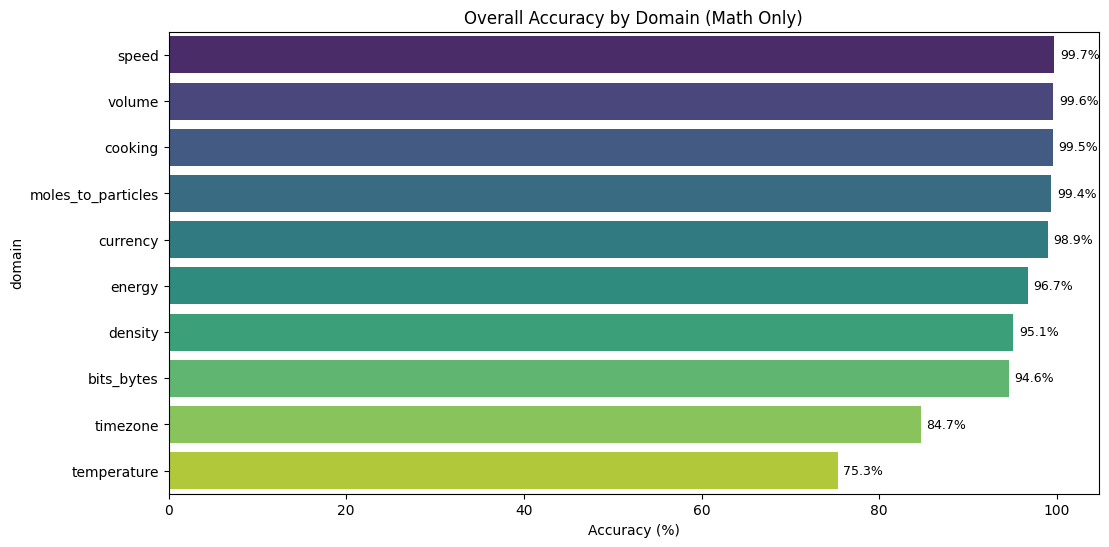

In [20]:
# get domain difficulty (overall) for math only
domain_avg = df_stats[df_stats['condition'] == 'math_only'].groupby('domain').agg({'accuracy_%': 'mean'}).sort_values('accuracy_%', ascending=False)
domain_avg
# plot domain difficulty
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='accuracy_%', y='domain', data=domain_avg, palette='viridis')
plt.title('Overall Accuracy by Domain (Math Only)')

# add accuracy labels on side of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=4)

plt.xlabel('Accuracy (%)')

Text(0.5, 0, 'Accuracy (%)')

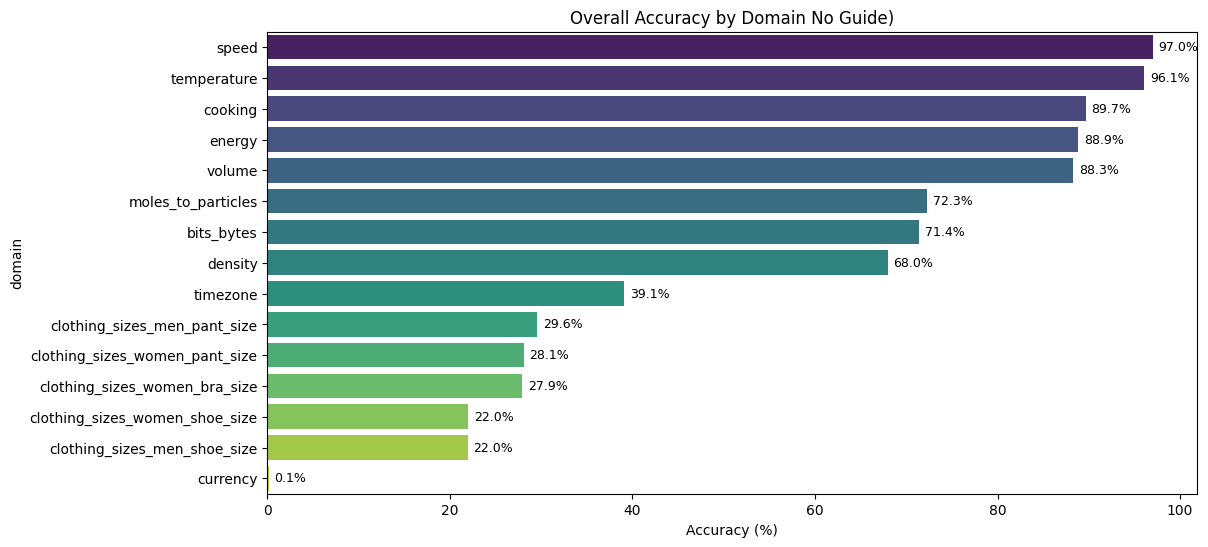

In [21]:
# no guide
# get domain difficulty (overall) for math only
domain_avg_no_guide = df_stats[df_stats['condition'] == 'no_guide'].groupby('domain').agg({'accuracy_%': 'mean'}).sort_values('accuracy_%', ascending=False)
domain_avg_no_guide 
# plot domain difficulty
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='accuracy_%', y='domain', data=domain_avg_no_guide, palette='viridis')
plt.title('Overall Accuracy by Domain No Guide)')

# add accuracy labels on side of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=4)

plt.xlabel('Accuracy (%)')

Text(0.5, 0, 'Accuracy (%)')

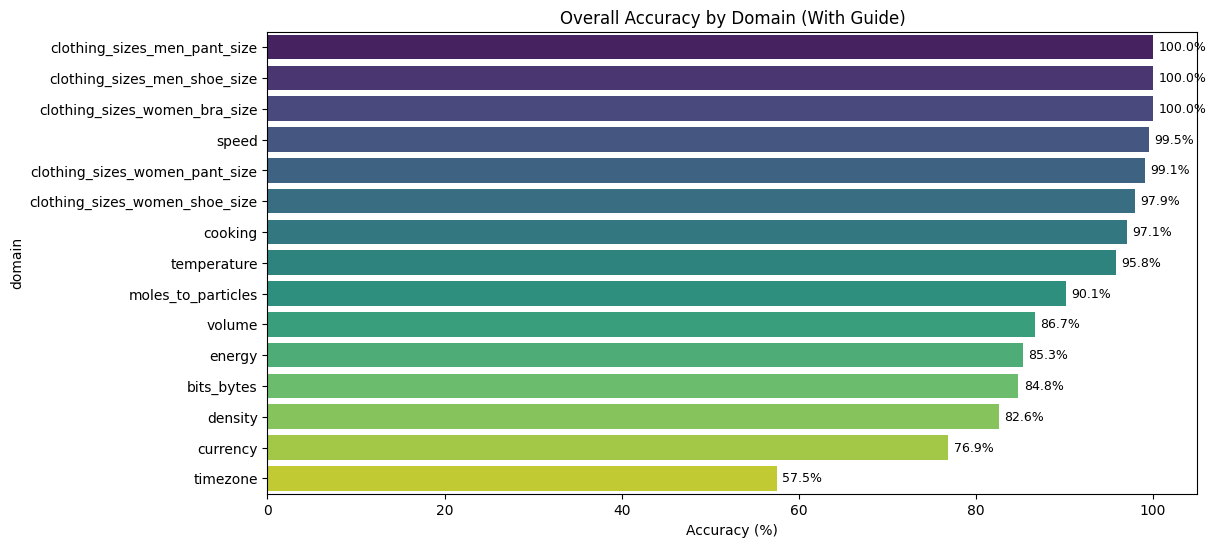

In [22]:
# get domain difficulty (overall) for math only
domain_avg_with_guide = df_stats[df_stats['condition'] == 'regular'].groupby('domain').agg({'accuracy_%': 'mean'}).sort_values('accuracy_%', ascending=False)
domain_avg_with_guide
# plot domain difficulty
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='accuracy_%', y='domain', data=domain_avg_with_guide, palette='viridis')
plt.title('Overall Accuracy by Domain (With Guide)')

# add accuracy labels on side of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=4)

plt.xlabel('Accuracy (%)')

In [23]:
# show how questions with distractors perform compared to those without, by domain

# group by distractor = null or not null, and get accuracy
df_int.groupby(['distractor','domain','condition', 'model']).agg({'is_correct': 'mean'}).reset_index()


,distractor,domain,condition,model,is_correct
0,RedBull,density,no_guide,deepseek-v3.1,0.395000
1,RedBull,density,no_guide,gpt-4o,0.663333
2,RedBull,density,no_guide,gpt-5.2,0.771667
3,RedBull,density,no_guide,llama-4,0.596667
4,RedBull,density,no_guide,qwen-coder,0.521667
...,...,...,...,...,...
2095,yogurt,energy,regular,gpt-5.2,0.988000
2096,yogurt,energy,regular,llama-4,0.897000
2097,yogurt,energy,regular,qwen-coder,0.692000
2098,yogurt,energy,regular,qwen3-235b-thinking,0.928000


/tmp/ipykernel_1269455/2343523329.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_int['has_distractor'] = df_int['distractor'].notna() & (df_int['distractor'] != 'null')
/tmp/ipykernel_1269455/2343523329.py:17: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.barplot(data=df_dist_stats, x='has_distractor', y='accuracy_%', hue='model',


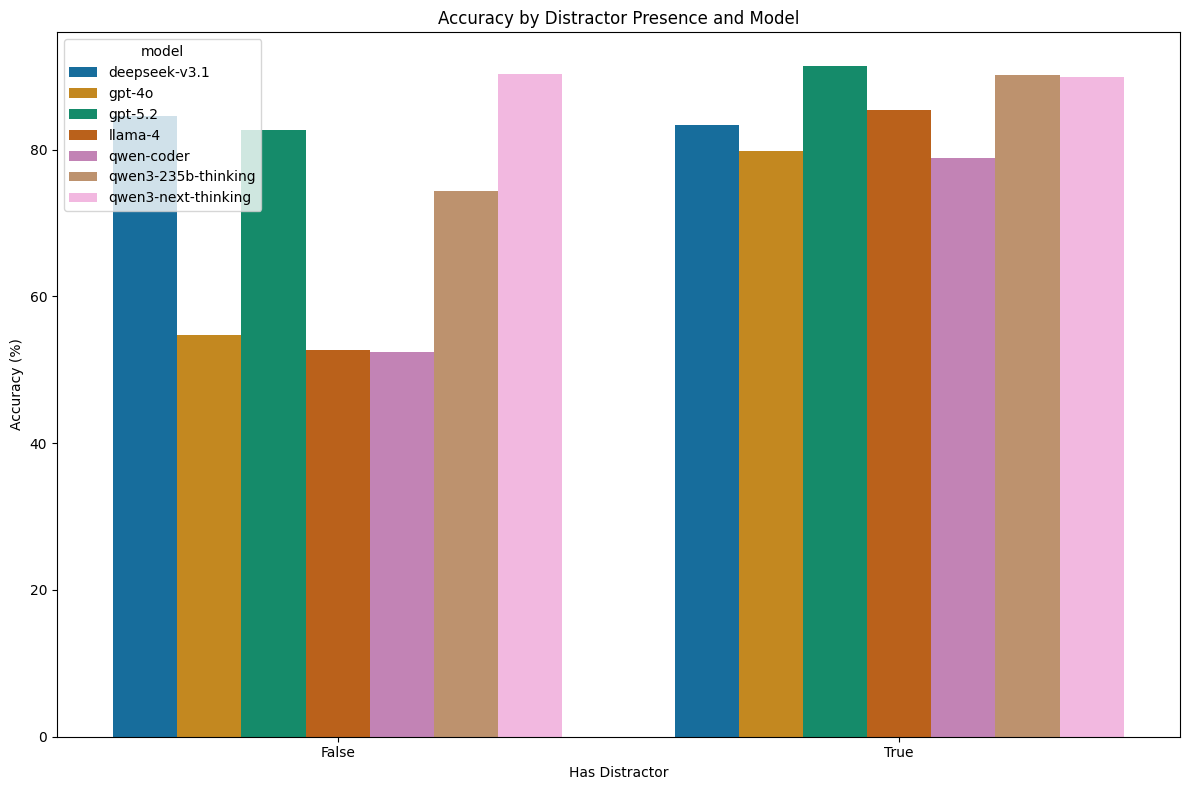

In [24]:
# plot accuracy by distractor or no distractor, by model
# Create a has_distractor flag on the raw data
df_int['has_distractor'] = df_int['distractor'].notna() & (df_int['distractor'] != 'null')

# Build stats grouped by has_distractor and model
df_dist_stats = (
    df_int
    .groupby(['model', 'has_distractor'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy'})
    .reset_index()
)
df_dist_stats['accuracy_%'] = df_dist_stats['accuracy'].mul(100)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=df_dist_stats, x='has_distractor', y='accuracy_%', hue='model',
            errorbar=('ci', 95), n_boot=10000, seed=42, palette=sns.color_palette('colorblind'),errwidth=2.5, capsize=0.15,)
plt.title('Accuracy by Distractor Presence and Model')
plt.xlabel('Has Distractor')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()


plt.show()

In [25]:
# need to extract difficulty from only timezone domain, no guide
df_timezone = df_int[(df_int['domain']=='timezone') & (df_int['condition']=='no_guide')].copy()
df_timezone['is_correct_pct'] = df_timezone['is_correct'].astype(float) * 100

# also keep aggregated stats for reference
df_timezone_stats = df_timezone.groupby(['difficulty', 'condition', 'model']).agg({'is_correct': 'mean'}).reset_index()
df_timezone_stats['accuracy_%'] = df_timezone_stats['is_correct'].mul(100)
df_timezone_stats.head(20)

,difficulty,condition,model,is_correct,accuracy_%
0,Easy,no_guide,deepseek-v3.1,0.761111,76.111111
1,Easy,no_guide,gpt-4o,0.208565,20.856481
2,Easy,no_guide,gpt-5.2,0.858565,85.856481
3,Easy,no_guide,llama-4,0.022222,2.222222
4,Easy,no_guide,qwen-coder,0.271759,27.175926
5,Easy,no_guide,qwen3-235b-thinking,0.234259,23.425926
6,Hard,no_guide,deepseek-v3.1,0.789198,78.919753
7,Hard,no_guide,gpt-4o,0.191667,19.166667
8,Hard,no_guide,gpt-5.2,0.854321,85.432099
9,Hard,no_guide,llama-4,0.022222,2.222222


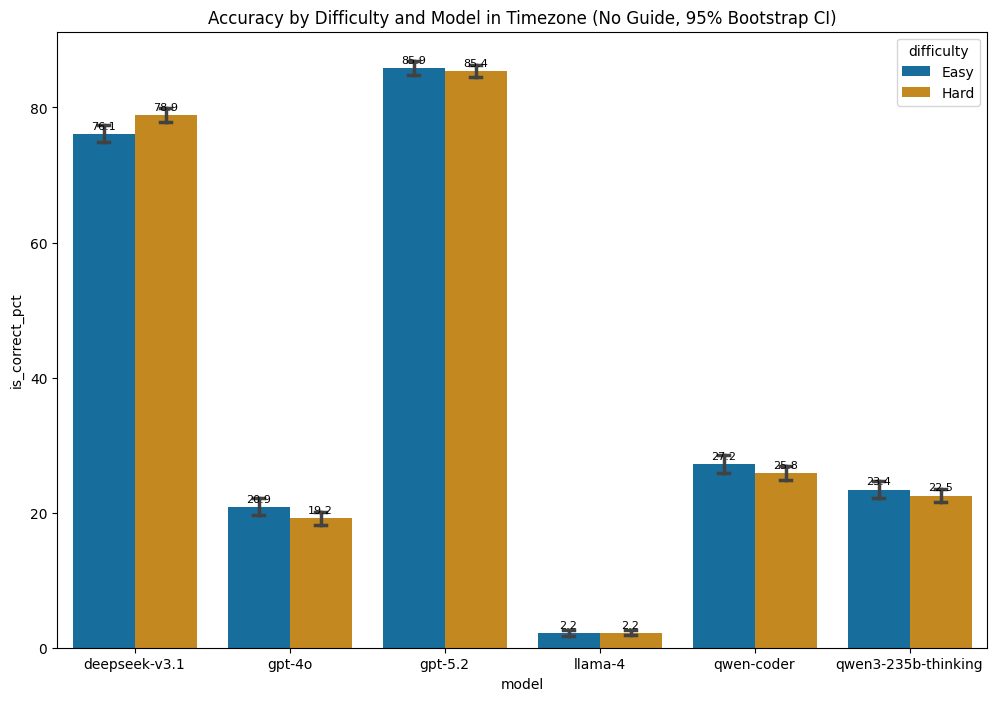

In [ ]:
# # plot each model's accuracy by difficulty in timezone, putting each model's easy and hard bars next to each other

# plt.figure(figsize=(12,8))

# # add accuracy labels on top of each bar
# ax = sns.barplot(data=df_timezone, x='model', y='is_correct_pct', hue='difficulty',
#                  errorbar=('ci', 95), n_boot=10000, seed=42, palette='colorblind',
#                  errwidth=2.5, capsize=0.15)
# plt.title('Accuracy by Difficulty and Model in Timezone (No Guide, 95% Bootstrap CI)')

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)


In [27]:
df_currency = df_int[(df_int['domain']=='currency') & (df_int['condition']=='no_guide')].copy()
df_currency['is_correct_pct'] = df_currency['is_correct'].astype(float) * 100

# also keep aggregated stats for reference
df_currency_stats = df_currency.groupby(['difficulty', 'condition', 'model']).agg({'is_correct': 'mean'}).reset_index()
df_currency_stats['accuracy_%'] = df_currency_stats['is_correct'].mul(100)
df_currency_stats.head(20)


,difficulty,condition,model,is_correct,accuracy_%
0,Easy,no_guide,deepseek-v3.1,0.000000,0.000000
1,Easy,no_guide,gpt-4o,0.003661,0.366071
2,Easy,no_guide,gpt-5.2,0.000714,0.071429
3,Easy,no_guide,llama-4,0.002589,0.258929
4,Easy,no_guide,qwen-coder,0.002500,0.250000
5,Easy,no_guide,qwen3-235b-thinking,0.000000,0.000000
6,Easy,no_guide,qwen3-next-thinking,0.000000,0.000000


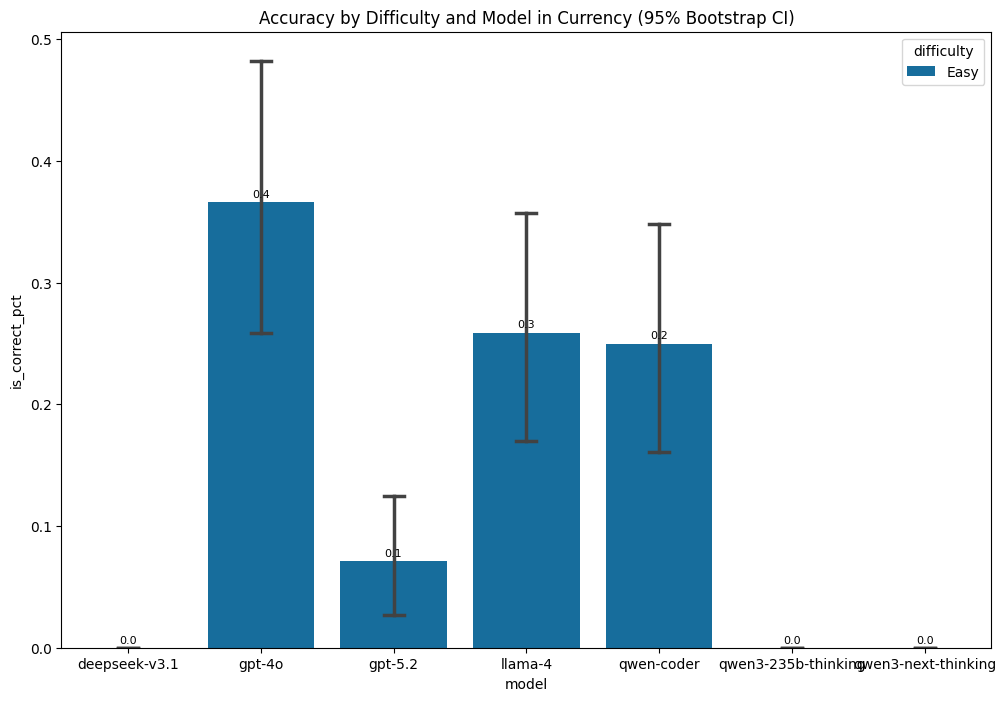

In [28]:
# plot each model's accuracy by difficulty in currency, putting each model's easy and hard bars next to each other (ALL CONDS)

plt.figure(figsize=(12,8))

# add accuracy labels on top of each bar
ax = sns.barplot(data=df_currency, x='model', y='is_correct_pct', hue='difficulty',
                 errorbar=('ci', 95), n_boot=10000, seed=42, palette='colorblind',
                 errwidth=2.5, capsize=0.15)
plt.title('Accuracy by Difficulty and Model in Currency (95% Bootstrap CI)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)

In [29]:
import re

def extract_reasoning_text(raw):
    """Extract reasoning trace from raw_response, checking multiple formats.
    
    Priority:
      1. [REASONING]...[/REASONING] — api.py wraps reasoning_content from the API
      2. <think>...</think>          — inline thinking tags (some Qwen responses)
      3. everything before the last <answer> tag — fallback for models like DeepSeek
         that dump chain-of-thought directly into the content with no wrapper
    """
    if pd.isna(raw):
        return ''
    raw = str(raw)
    # 1. [REASONING]...[/REASONING]
    m = re.search(r'\[REASONING\]\s*(.*?)\s*\[/REASONING\]', raw, re.DOTALL)
    if m:
        return m.group(1).strip()
    # 2. <think>...</think>
    m = re.search(r'<think>(.*?)</think>', raw, re.DOTALL)
    if m:
        return m.group(1).strip()
    # 3. fallback: everything before the last <answer> tag is reasoning
    ans_matches = list(re.finditer(r'<answer>', raw, re.IGNORECASE))
    if ans_matches:
        reasoning_part = raw[:ans_matches[-1].start()].strip()
        # only count it if there's substantial text (>50 chars) to avoid
        # false positives from short preambles like "The answer is"
        if len(reasoning_part) > 50:
            return reasoning_part
    return ''

# only apply to reasoning models
df_reason = df_int[df_int['model'].isin(REASONING_MODELS)].copy()

# extract reasoning text and approximate token count (~0.75 words per token)
df_reason['reasoning_text'] = df_reason['raw_response'].apply(extract_reasoning_text)
df_reason['reasoning_word_count'] = df_reason['reasoning_text'].str.split().str.len().fillna(0).astype(int)
df_reason['reasoning_tokens_approx'] = (df_reason['reasoning_word_count'] / 0.75).round(0).astype(int)

# use API-provided reasoning_tokens where available, otherwise use approximation
df_reason['reasoning_tokens_final'] = df_reason['reasoning_tokens'].fillna(df_reason['reasoning_tokens_approx'])
# if API value is 0 but we have text, prefer approximation
mask_zero_api = (df_reason['reasoning_tokens_final'] == 0) & (df_reason['reasoning_tokens_approx'] > 0)
df_reason.loc[mask_zero_api, 'reasoning_tokens_final'] = df_reason.loc[mask_zero_api, 'reasoning_tokens_approx']

# filter to rows that actually have reasoning
df_reasoning = df_reason[df_reason['reasoning_tokens_final'] > 0].copy()

print(f"{len(df_reasoning):,} rows with reasoning traces (out of {len(df_reason):,} reasoning-model rows)")
print(f"Models: {df_reasoning['model'].unique().tolist()}")
print(f"\nSource breakdown:")
has_api = df_reasoning['reasoning_tokens'].notna() & (df_reasoning['reasoning_tokens'] > 0)
print(f"  API-provided reasoning_tokens: {has_api.sum():,}")
print(f"  Approximated from text:        {(~has_api).sum():,}")
print(f"\nSummary stats (reasoning_tokens_final):")
df_reasoning.groupby('model')['reasoning_tokens_final'].describe().round(0)

503,495 rows with reasoning traces (out of 907,884 reasoning-model rows)
Models: ['deepseek-v3.1', 'gpt-5.2', 'qwen3-235b-thinking', 'qwen3-next-thinking']

Source breakdown:
  API-provided reasoning_tokens: 94,183
  Approximated from text:        409,312

Summary stats (reasoning_tokens_final):


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
deepseek-v3.1,12888.0,198.0,535.0,1.0,49.0,77.0,123.0,9667.0
gpt-5.2,94183.0,268.0,349.0,2.0,65.0,125.0,322.0,6134.0
qwen3-235b-thinking,198789.0,1438.0,1504.0,47.0,409.0,787.0,1919.0,14768.0
qwen3-next-thinking,197635.0,1811.0,1451.0,69.0,644.0,1396.0,2529.0,16521.0


In [30]:
# reasoning by domain
df_reasoning.groupby(['domain', 'model'])['reasoning_tokens_final'].describe().round(0)
# reasoning by domain & condition
df_reasoning.groupby(['domain', 'condition', 'model'])['reasoning_tokens_final'].describe().round(0)


count    mean     std    min  \
domain     condition model                                                 
bits_bytes math_only deepseek-v3.1            2.0    52.0    30.0   31.0   
                     qwen3-235b-thinking    600.0   471.0   433.0  105.0   
                     qwen3-next-thinking    597.0   568.0   570.0   69.0   
           no_guide  qwen3-235b-thinking    600.0   897.0  1137.0  139.0   
                     qwen3-next-thinking    599.0   982.0   902.0  148.0   
...                                           ...     ...     ...    ...   
volume     no_guide  qwen3-235b-thinking  18600.0  1375.0  1662.0  108.0   
                     qwen3-next-thinking  18600.0  1188.0   888.0  155.0   
           regular   deepseek-v3.1          361.0  2329.0  1219.0   36.0   
                     qwen3-235b-thinking  18597.0  1688.0  1504.0   92.0   
                     qwen3-next-thinking  18599.0  2009.0  1418.0  140.0   

                                             25%     50%     75%      max  
domain     condition model                                                 
bits_bytes math_only deepseek-v3.1          42.0    52.0    62.0     73.0  
                     qwen3-235b-thinking   224.0   325.0   492.0   4020.0  
                     qwen3-next-thinking   204.0   345.0   640.0   3295.0  
           no_guide  qwen3-235b-thinking   257.0   402.0   982.0   7085.0  
                     qwen3-next-thinking   329.0   727.0  1194.0   4960.0  
...                                          ...     ...     ...      ...  
volume     no_guide  qwen3-235b-thinking   395.0   615.0  1492.0  12316.0  
                     qwen3-next-thinking   457.0   855.0  1766.0   7247.0  
           regular   deepseek-v3.1        1547.0  2189.0  2937.0   7917.0  
                     qwen3-235b-thinking   599.0  1180.0  2191.0   9264.0  
                     qwen3-next-thinking   936.0  1608.0  2914.0   8179.0  

[104 rows x 8 columns]

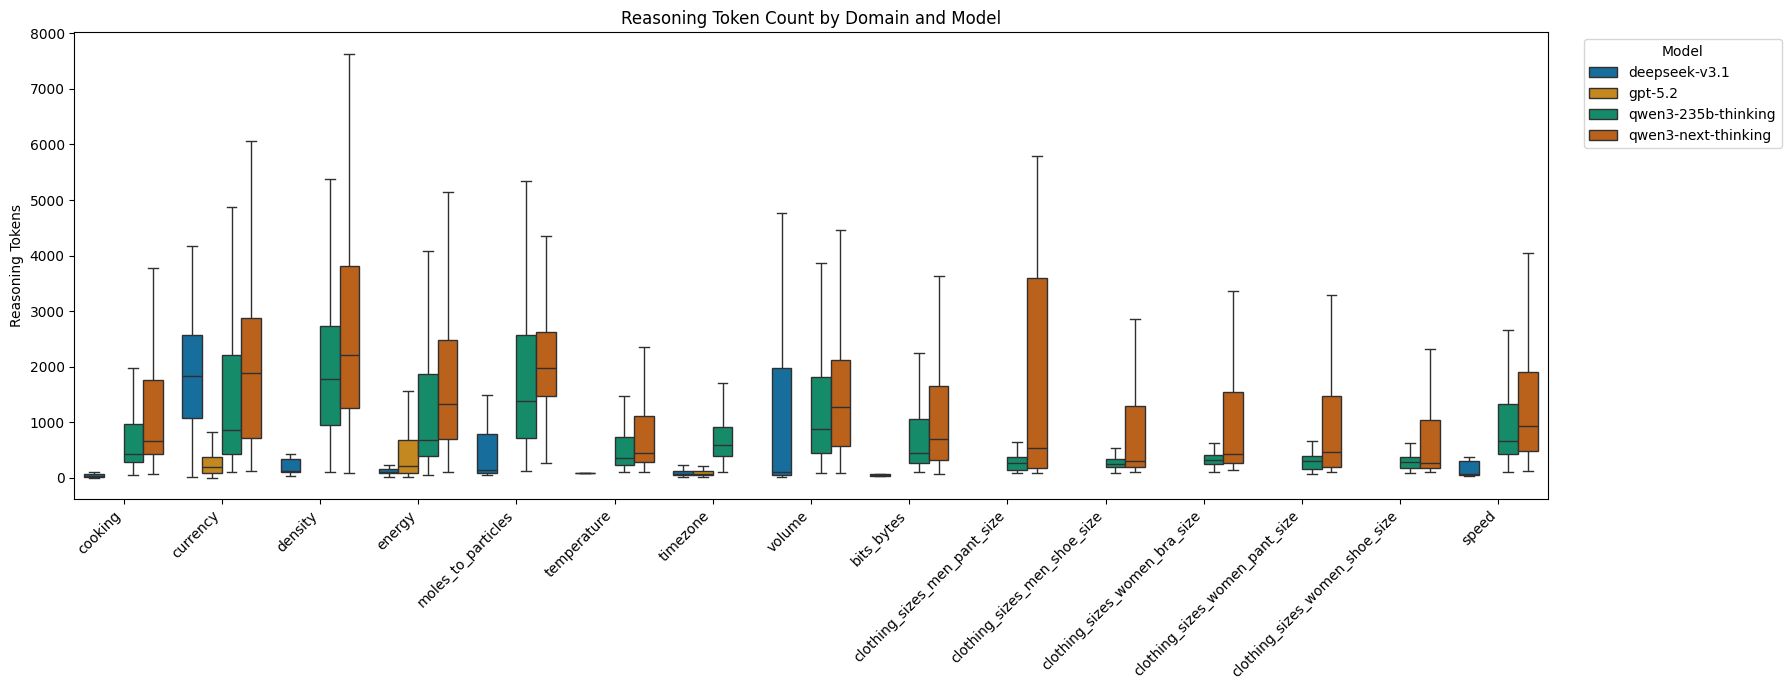

In [31]:
# boxplot: reasoning tokens by model × domain
fig, ax = plt.subplots(figsize=(18, 7))
sns.boxplot(
    data=df_reasoning, x='domain', y='reasoning_tokens_final', hue='model',
    showfliers=False,  # hide outliers so boxes are readable
    palette='colorblind', ax=ax,
)

ax.set_title('Reasoning Token Count by Domain and Model')
ax.set_ylabel('Reasoning Tokens')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

104 points (model × condition × domain, reasoning models only)


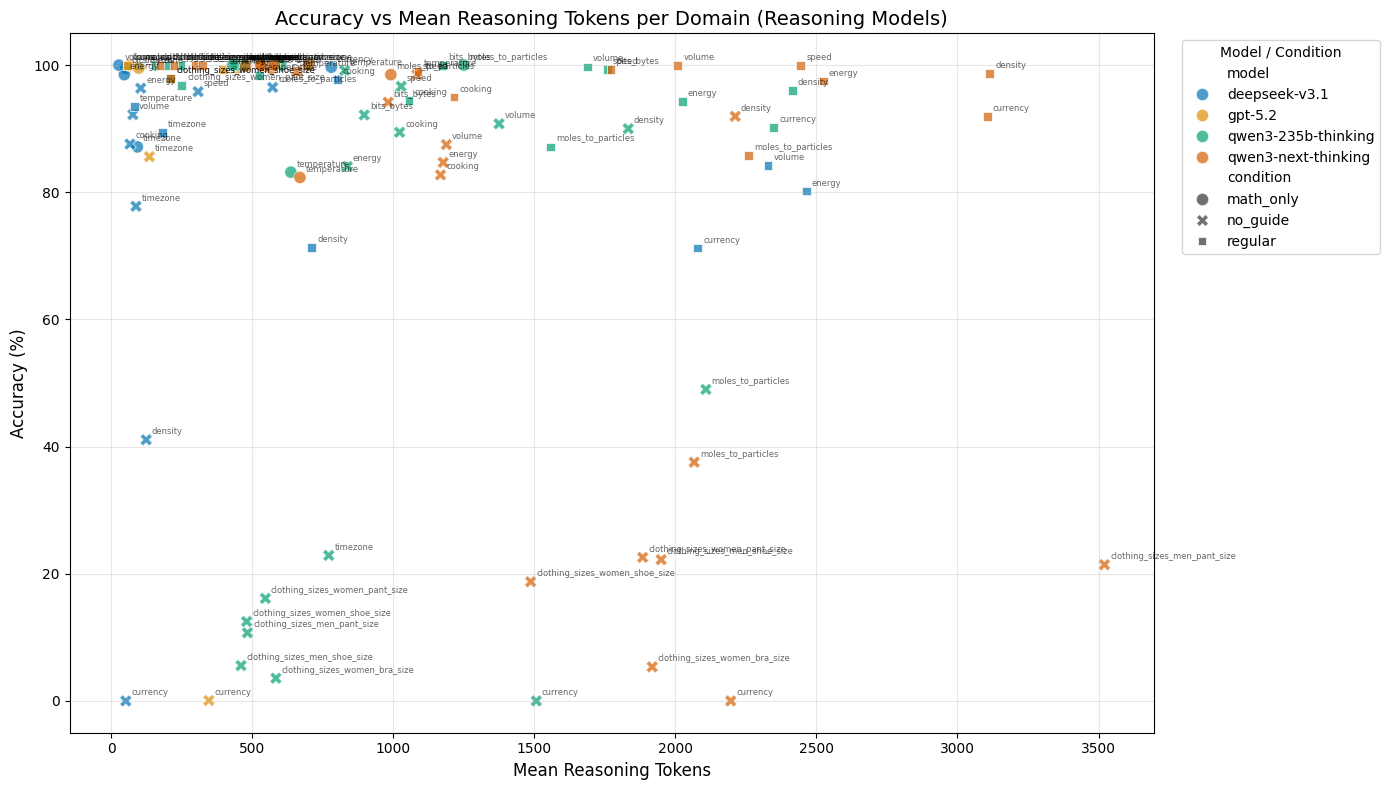

In [32]:
# ── scatter: mean reasoning tokens (x) vs accuracy (y) per model × domain ──
# each dot = one model+condition+domain combo (reasoning models only)

# aggregate mean reasoning tokens at the same level as df_stats
reasoning_agg = (
    df_reasoning
    .groupby(['model', 'condition', 'domain'])['reasoning_tokens_final']
    .mean()
    .reset_index()
    .rename(columns={'reasoning_tokens_final': 'mean_reasoning_tokens'})
)

# merge with df_stats_ci (which has accuracy_%)
scatter_df = df_stats.merge(reasoning_agg, on=['model', 'condition', 'domain'], how='inner')
print(f"{len(scatter_df)} points (model × condition × domain, reasoning models only)")

fig, ax = plt.subplots(figsize=(14, 8))
sns.scatterplot(
    data=scatter_df, x='mean_reasoning_tokens', y='accuracy_%',
    hue='model', style='condition', s=80, alpha=0.7,
    palette='colorblind', ax=ax,
)

# label each dot with its domain
for _, row in scatter_df.iterrows():
    ax.annotate(
        row['domain'], (row['mean_reasoning_tokens'], row['accuracy_%']),
        fontsize=6, alpha=0.6, textcoords='offset points', xytext=(4, 4),
    )

ax.set_xlabel('Mean Reasoning Tokens', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Mean Reasoning Tokens per Domain (Reasoning Models)', fontsize=14)
ax.legend(title='Model / Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# accuracy comparing womens vs mens clothing domains

# tag each clothing row with gender
clothing_domains = df_int[df_int['domain'].str.startswith('clothing_sizes')].copy()
clothing_domains['gender'] = clothing_domains['domain'].apply(
    lambda d: 'men' if '_men_' in d else ('women' if '_women_' in d else 'other')
)
# also keep the specific sub-domain (shoe, pant, bra)
clothing_domains['sub_domain'] = (
    clothing_domains['domain']
    .str.replace('clothing_sizes_men_', '', regex=False)
    .str.replace('clothing_sizes_women_', '', regex=False)
)

print(f"Clothing rows: {len(clothing_domains):,}")
print(f"Gender split:\n{clothing_domains['gender'].value_counts()}")
print(f"\nSub-domains:\n{clothing_domains['sub_domain'].value_counts()}")
print(f"\nOverall accuracy by gender:")
print(clothing_domains.groupby('gender')['is_correct'].mean())





Clothing rows: 3,822
Gender split:
gender
women    2674
men      1148
Name: count, dtype: int64

Sub-domains:
sub_domain
bra_size     1568
shoe_size    1428
pant_size     826
Name: count, dtype: int64

Overall accuracy by gender:
gender
men      0.622822
women    0.629020
Name: is_correct, dtype: float64


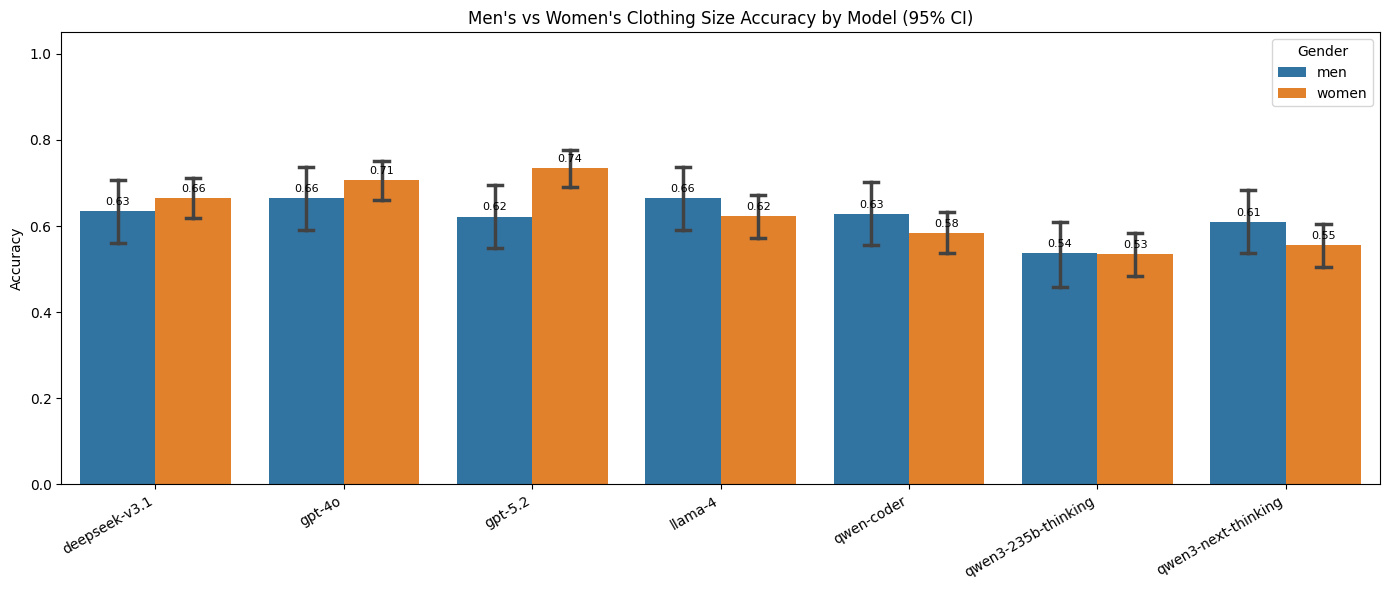

In [35]:
# ── bar plot: men vs women accuracy by model, with bootstrap CIs ──

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=clothing_domains,
    x='model', y='is_correct', hue='gender',
    hue_order=['men', 'women'],
    errorbar=('ci', 95), n_boot=10000, seed=42,
    errwidth=2.5, capsize=0.15,
    ax=ax,
)
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.set_title("Men's vs Women's Clothing Size Accuracy by Model (95% CI)")
ax.set_ylim(0, 1.05)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=3)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [38]:
df_reasoning_currency = df_reasoning[df_reasoning['domain'] == 'currency'].copy()
df_reasoning_timezone = df_reasoning[df_reasoning['domain'] == 'timezone'].copy()


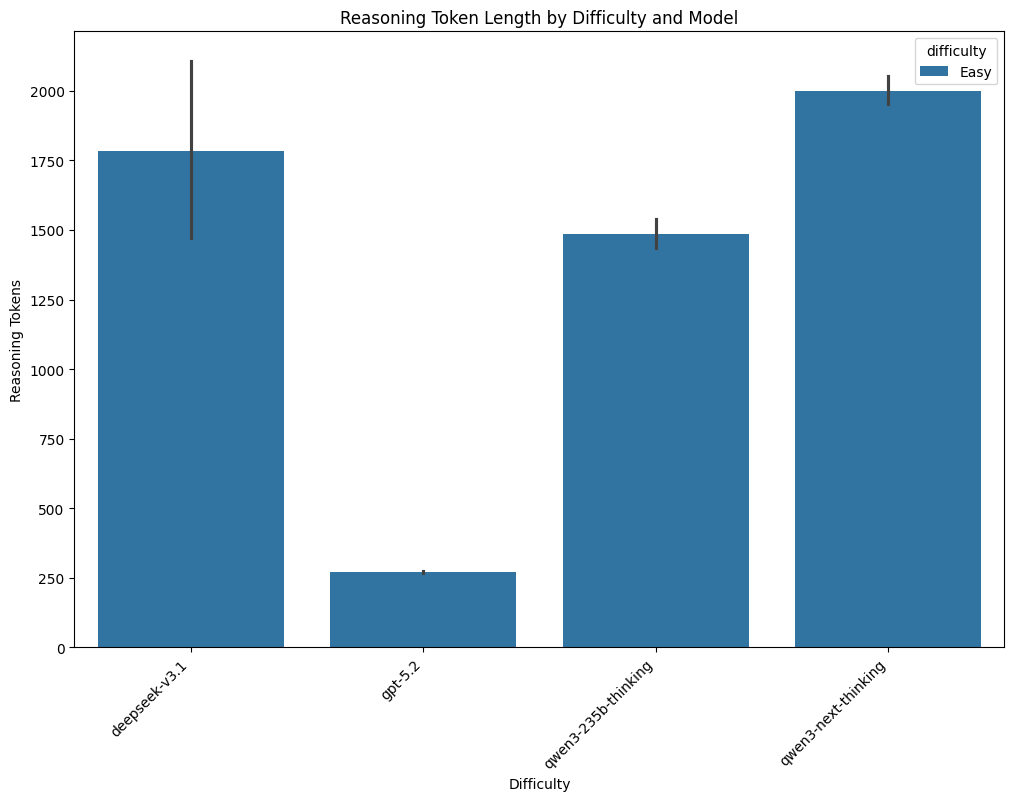

In [37]:
# compare reasoning token length for easy vs hard CURRENCY questions
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df_reasoning_currency, x='model', y='reasoning_tokens_final', hue='difficulty', ax=ax)
ax.set_title('Reasoning Token Length by Difficulty and Model')
ax.set_xlabel('Difficulty')
ax.set_ylabel('Reasoning Tokens')
plt.xticks(rotation=45, ha='right')
plt.show()

([0, 1, 2, 3],
 [Text(0, 0, 'deepseek-v3.1'),
  Text(1, 0, 'gpt-5.2'),
  Text(2, 0, 'qwen3-235b-thinking'),
  Text(3, 0, 'qwen3-next-thinking')])

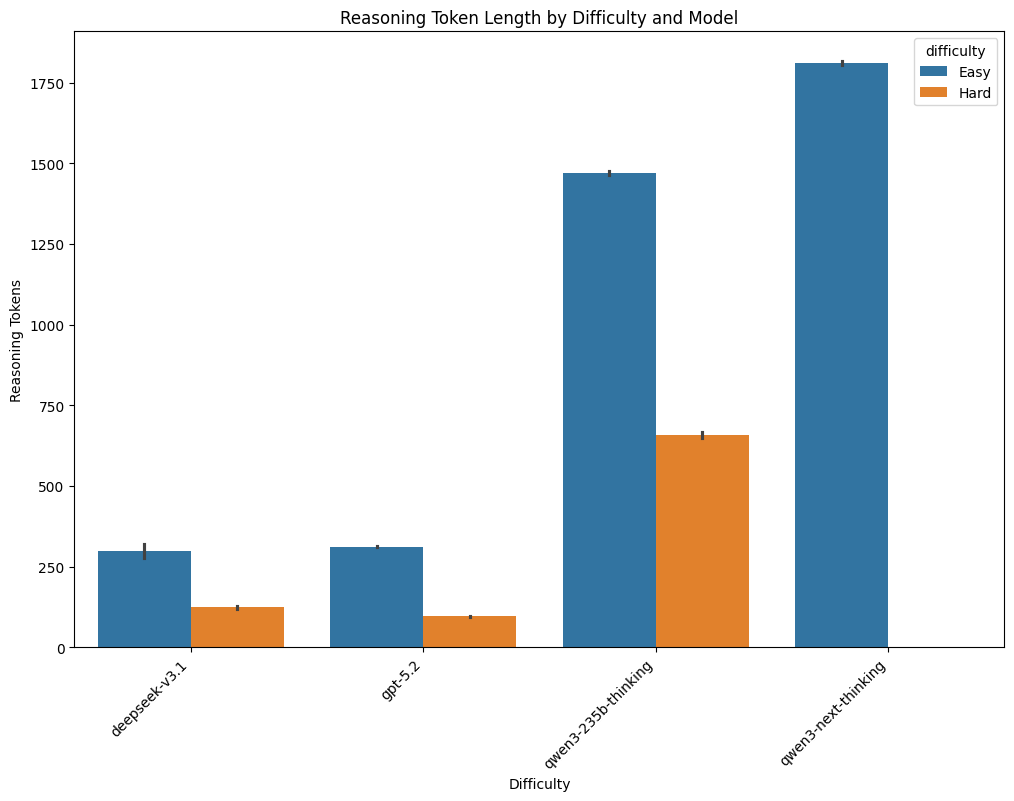

In [39]:
# compare reasoning token length for easy vs hard TIMEZONE questions
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df_reasoning, x='model', y='reasoning_tokens_final', hue='difficulty', ax=ax)
ax.set_title('Reasoning Token Length by Difficulty and Model')
ax.set_xlabel('Difficulty')
ax.set_ylabel('Reasoning Tokens')
plt.xticks(rotation=45, ha='right')